
### **Project : Predictive Maintenance – Engine Health Prediction**

**Problem Statement:**
Predict engine failures using sensor data (RPM, oil/fuel pressures, temperatures) to enable proactive maintenance and reduce unplanned downtime in automotive and industrial applications.

**Dataset:**
* **Source:** [Automotive Vehicles Engine Health Dataset – Kaggle](https://www.kaggle.com/datasets/parvmodi/automotive-vehicles-engine-health-dataset)
* **Features:** Engine RPM, Lubrication Oil Pressure, Fuel Pressure, Coolant Pressure, Lubrication Oil Temp, Coolant Temp
* **Target:** Engine Condition (binary: 0 = normal, 1 = potential failure)
* **Challenge:** Imbalanced classes

**Models Trained & Results:**
| Metric              | Random Forest | Gradient Boosting |
| ------------------- | ------------- | ----------------- |
| Accuracy            | 70%           | 67%               |
| F1-score (Weighted) | 0.70          | 0.67              |
| Precision (Class 1) | 0.73          | 0.69              |
| Recall (Class 1)    | 0.65          | 0.62              |
| ROC-AUC Score       | 0.766         | 0.723             |

**Confusion Matrix Insights:**
* Random Forest correctly identified 1,608 engine failure cases, while Gradient Boosting identified 1,547.
* Random Forest had slightly fewer false negatives, making it better at detecting potential failures.


In [2]:
# ==============================
# Project 7: Predictive Maintenance
# ==============================

# 1. Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE



In [ ]:
# ==============================
# 2. Load Dataset
# ==============================
# Dataset https://www.kaggle.com/datasets/parvmodi/automotive-vehicles-engine-health-dataset
df = pd.read_csv("Data/engine_data.csv")  # Replace with your dataset path
print("Dataset shape:", df.shape)
print(df.head())



Dataset shape: (19535, 7)
   Engine rpm  Lub oil pressure  Fuel pressure  Coolant pressure  \
0         700          2.493592      11.790927          3.178981   
1         876          2.941606      16.193866          2.464504   
2         520          2.961746       6.553147          1.064347   
3         473          3.707835      19.510172          3.727455   
4         619          5.672919      15.738871          2.052251   

   lub oil temp  Coolant temp  Engine Condition  
0     84.144163     81.632187                 1  
1     77.640934     82.445724                 0  
2     77.752266     79.645777                 1  
3     74.129907     71.774629                 1  
4     78.396989     87.000225                 0  


In [4]:
# ==============================
# 3. Preprocessing
# ==============================
# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Scale sensor features
sensor_cols = [
    'Engine rpm', 'Lub oil pressure', 'Fuel pressure', 
    'Coolant pressure', 'lub oil temp', 'Coolant temp'
]

scaler = StandardScaler()
df[sensor_cols] = scaler.fit_transform(df[sensor_cols])

# Target variable
# Assuming "Engine Condition" is a numeric label
X = df[sensor_cols]
y = df['Engine Condition']



Missing values:
 Engine rpm          0
Lub oil pressure    0
Fuel pressure       0
Coolant pressure    0
lub oil temp        0
Coolant temp        0
Engine Condition    0
dtype: int64


In [5]:
# ==============================
# 4. Handle Imbalanced Classes
# ==============================
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

print("Resampled dataset shape:", X_res.shape)
print(pd.Series(y_res).value_counts())



Resampled dataset shape: (24634, 6)
Engine Condition
1    12317
0    12317
Name: count, dtype: int64


In [6]:
# ==============================
# 5. Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)



In [11]:
# 6. Train Random Forest
# ==============================
rf_clf = RandomForestClassifier(n_estimators=300, max_depth=15, random_state=42)
rf_clf.fit(X_train, y_train)

# ==============================
# 7. Train Gradient Boosting
# ==============================
gb_clf = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=6)
gb_clf.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.05
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,6
,min_impurity_decrease,0.0
,init,None


In [12]:
# ==============================
# 8. Evaluate Both Models
# ==============================
def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    print(f"===== {model_name} =====")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    if len(np.unique(y)) == 2:
        y_prob = model.predict_proba(X_test)[:,1]
        roc_auc = roc_auc_score(y_test, y_prob)
        print(f"ROC-AUC Score: {roc_auc:.4f}")
    print("\n")

# Evaluate Random Forest
evaluate_model(rf_clf, X_test, y_test, "Random Forest")

# Evaluate Gradient Boosting
evaluate_model(gb_clf, X_test, y_test, "Gradient Boosting")

===== Random Forest =====
Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.76      0.72      2448
           1       0.73      0.65      0.69      2479

    accuracy                           0.70      4927
   macro avg       0.71      0.70      0.70      4927
weighted avg       0.71      0.70      0.70      4927

Confusion Matrix:
[[1857  591]
 [ 871 1608]]
ROC-AUC Score: 0.7662


===== Gradient Boosting =====
Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.71      0.68      2448
           1       0.69      0.62      0.65      2479

    accuracy                           0.67      4927
   macro avg       0.67      0.67      0.67      4927
weighted avg       0.67      0.67      0.67      4927

Confusion Matrix:
[[1741  707]
 [ 932 1547]]
ROC-AUC Score: 0.7226




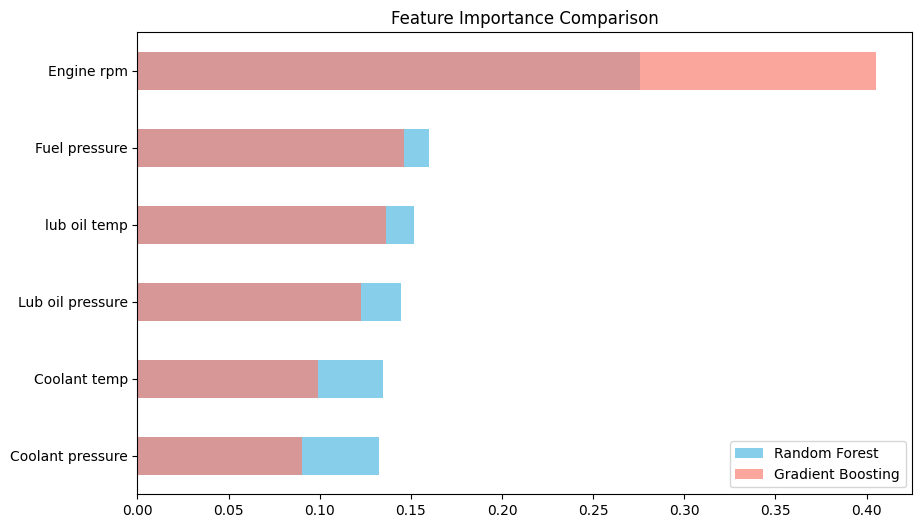

In [13]:
# 9. Feature Importance Comparison
# ==============================
rf_feat = pd.Series(rf_clf.feature_importances_, index=sensor_cols).sort_values(ascending=True)
gb_feat = pd.Series(gb_clf.feature_importances_, index=sensor_cols).sort_values(ascending=True)

plt.figure(figsize=(10,6))
rf_feat.plot(kind='barh', color='skyblue', label='Random Forest')
gb_feat.plot(kind='barh', color='salmon', label='Gradient Boosting', alpha=0.7)
plt.title("Feature Importance Comparison")
plt.legend()
plt.show()